# Foraging Paralysis as a Collapse Mechanism: the computations

This notebook walks through the thesis **chapter by chapter** and recomputes every central claim.
The formulas are stated in the text, the computation follows directly below, and each check prints
the computed value next to the value printed in the thesis (✓ = agrees to the printed digits).
All figures of the thesis are produced along the way.

**Structure.** `thesis_code.py` sits in the same folder and is imported as a library, like `numpy`.
The short mathematical steps (cascade, thresholds, fits) are written out here in the notebook.
Only the technical machinery (integrators with events, the delay solver, the figure layout) is
called from the library.

**How to run.** Run all cells from top to bottom (*Run All*). Everything takes about one minute,
most of it for the basin figure in Section 5.4. The only slow table (Table B.3) is switched off by default.

## 0  Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from IPython.display import Image, display

import thesis_code as tc
%matplotlib inline

P  = tc.PAR          # all parameters (notation table, Appendix A)
m0 = P.m0


def check(name, value, thesis, tol=None):
    """Compare with the thesis: tolerance = half a unit in the last printed digit."""
    t = tc._tol_from_str(thesis) if tol is None else tol
    ok = abs(value - float(thesis)) <= t * (1 + 1e-9)
    print(f"{'✓' if ok else '✗'}  {name:<48} code: {value:<14.7g} thesis: {thesis}")


def show(name):
    """Produce a thesis figure (PDF + PNG in figs/) and display it."""
    file = tc.FIGURES[name]("figs")
    display(Image(f"figs/{file}.png", width=800))


for k, v in vars(P).items():
    print(f"{k:>6} = {v}")
print(f" kappa = gB/phi = {P.kap:.4f} g,   a* = kappa + gA v/L = {P.astar:.4f} g")

     L = 2000.0
  amin = 0.25
  amax = 0.25
 sigma = 0.75
     v = 5000.0
     b = 500.0
   phi = 0.1111111111111111
   tau = 12.0
     c = 0.1
    gA = 0.007
    gB = 0.018
    m0 = 0.154
  beta = 0.109
    h0 = 0.002
  zeta = 6.09
    nu = 3.0
 kappa = gB/phi = 0.1620 g,   a* = kappa + gA v/L = 0.1795 g


### The result in one picture (Figure 1.1)

Three hornet loads organise everything that follows: above about 6 hornets the stores stop growing,
above about 8 the colony loses its positive equilibrium, and above about 10 collapse is proved.
Dots hold forager mortality at $m_0$, bar ends let the whole mortality scale with flight activity.

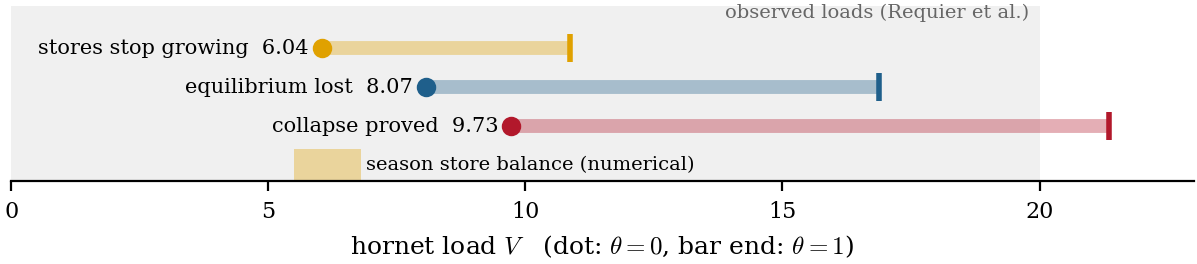

In [2]:
show("ladder")

## Chapter 3  The models of Khoury et al.

### 3.1  The 2011 model: critical mortality

At equilibrium $mF = LN/(w+N)$ and $R = mF/H$. With $u = F/N$ this gives
$m u = (1-u)(\alpha - \sigma u)$ and $N = L/(mu) - w$. The equilibrium disappears when $N = 0$,
that is when $mu = L/w$. Substituting yields an equation in $u$ alone:
$$(1-u)(\alpha_{\min} - \sigma u) = L/w .$$

In [3]:
w  = 27000.0
Lw = P.L / w
u_c = brentq(lambda u: (1 - u) * (P.amin - P.sigma * u) - Lw, 0.0, P.amin / P.sigma)
m_c = Lw / u_c
check("critical mortality 2011", m_c, "0.355")
check("critical flight lifespan 1/m_c [d]", 1 / 0.355, "2.8")
check("return threshold amin/sigma", P.amin / P.sigma, "0.3333", tol=1e-4)

✓  critical mortality 2011                          code: 0.3551967      thesis: 0.355
✓  critical flight lifespan 1/m_c [d]               code: 2.816901       thesis: 2.8
✓  return threshold amin/sigma                      code: 0.3333333      thesis: 0.3333


### 3.2  The 2013 model (Figure 3.1)

Four compartments (brood, hive bees, foragers, food stores) after Khoury et al. (2013), Fig. 1,
with the two hornet impacts studied in this thesis drawn in red.

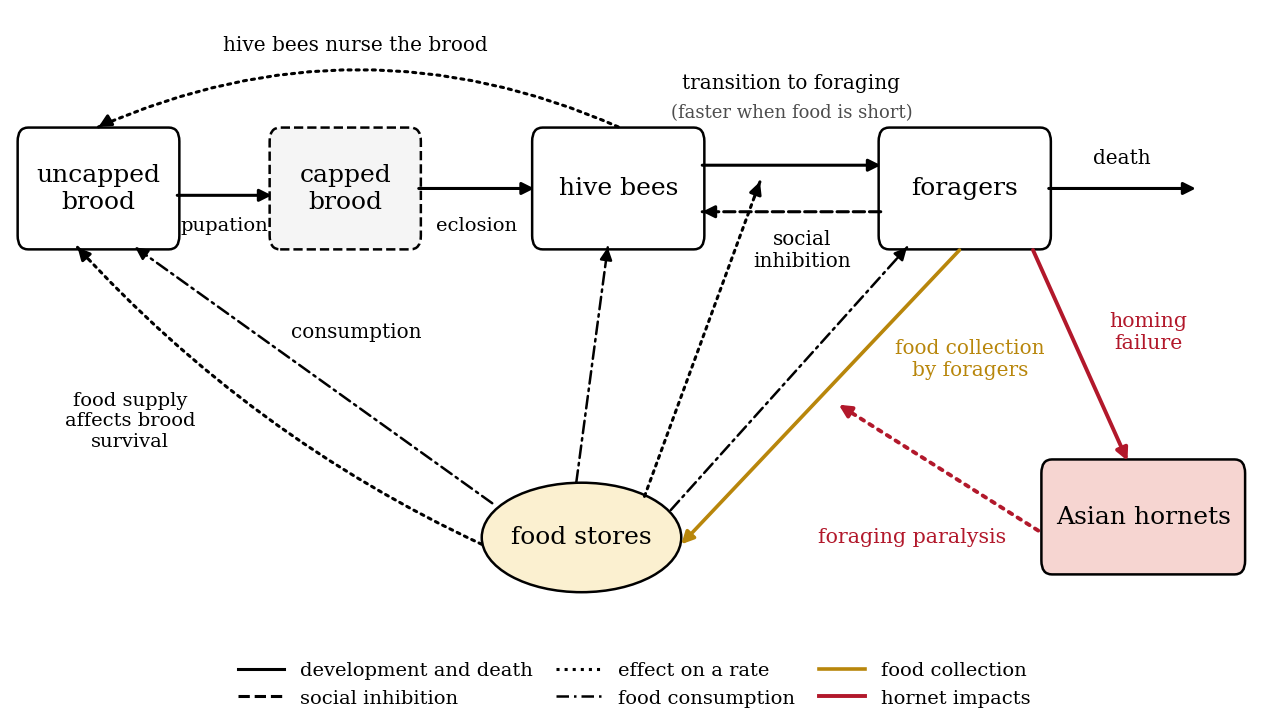

In [4]:
show("schema_bio")

### 3.3  The daily balance of a forager
She brings in $c = 0.1$ g, eats $\gamma_A = 0.007$ g, and replacing her costs $\kappa m_0$ per day.

In [5]:
check("c / gA  (multiple of her own needs)", P.c / P.gA, "14", tol=0.5)
check("kappa m0 [g/d]", P.kap * m0, "0.025")

✓  c / gA  (multiple of her own needs)              code: 14.28571       thesis: 14
✓  kappa m0 [g/d]                                   code: 0.024948       thesis: 0.025


### Appendix C  Reproducing Khoury 2013 at $m = 0.42$, $p = 1$

The cascade step by step (with unrounded intermediate values):
1. Food balance: $P = c/\gamma_A - 1 - \gamma_B m/(\gamma_A\phi)$, then $J = F/H = 1/P$.
2. Recruitment: $mJ + \sigma J/(1+J) - \alpha_{\min} = \alpha_{\max}\,\psi(f)$ determines $f^*$.
3. Brood balance: $H^* = L s(f^*)/(mJ) - v$.

In [6]:
m, p = 0.42, 1.0
Pq  = P.c * p / P.gA - 1 - P.kap * m / P.gA
J   = 1 / Pq
den = m * J + P.sigma * J / (1 + J) - P.amin      # = amax * psi(f*)
psi = den / P.amax
f   = P.b * np.sqrt(1 / psi - 1)
s   = 1 - psi
H   = P.L * s / (m * J) - P.v
F   = J * H
check("P", Pq, "3.5657")
check("denominator", den, "0.03206")
check("f* [g]", f, "1303.7")
check("H*", H, "9802.4")
check("F*", F, "2749.1")
print("\nX, s(f*), B* exact:", psi, s, m * F / P.phi, " (the thesis rounds intermediate values: 0.12824, 0.87175, 10391.6)")

✓  P                                                code: 3.565714       thesis: 3.5657
✓  denominator                                      code: 0.0320563      thesis: 0.03206
✓  f* [g]                                           code: 1303.724       thesis: 1303.7
✓  H*                                               code: 9802.381       thesis: 9802.4
✓  F*                                               code: 2749.065       thesis: 2749.1

X, s(f*), B* exact: 0.12822518532781357 0.8717748146721864 10391.465894868585  (the thesis rounds intermediate values: 0.12824, 0.87175, 10391.6)


**The two errors in the appendix of Khoury 2013.** (a) The printed denominator has a wrong sign
and becomes negative. (b) The printed quadratic equation for the critical mortality has the wrong roots.

In [7]:
printed = P.sigma / (Pq + 1) - m / Pq - P.amin
check("printed denominator (negative)", printed, "-0.20352")

k = P.gB / (P.gA * P.phi); A = P.c / P.gA - 1
correct   = [k * (P.amin * k + 1),
             -(2 * P.amin * A * k + (P.amin - P.sigma) * k + A + 1),
             A * (P.amin * A + P.amin - P.sigma)]
published = [k, -(P.sigma * k - P.c / P.gA), P.asum + P.sigma - P.sigma * P.c / P.gA]
print("correct equation, roots:  ", np.sort(np.roots(correct).real))     # 0.4010, 0.5952
print("published equation, roots:", np.sort(np.roots(published).real))   # -0.5766, 0.7093
check("(A8) = 31/54", P.phi * P.gA / P.gB * (P.c / P.gA - 1), "0.5741")

✓  printed denominator (negative)                   code: -0.2035206     thesis: -0.20352
correct equation, roots:   [0.40103192 0.5951994 ]
published equation, roots: [-0.5765681   0.70928415]
✓  (A8) = 31/54                                     code: 0.5740741      thesis: 0.5741


## Chapter 4  Calibration

The hornet enters the model through two functions fitted to the field data of Requier et al. (2019).

### 4.3.2  Foraging activity $p(V) = e^{-\beta V}$
Least squares for $-\ln p_i = \beta V_i$ (a line through the origin):
$$\hat\beta = \frac{\sum V_i(-\ln p_i)}{\sum V_i^2}.$$

In [8]:
V_dig = np.array([5.0, 10.0, 15.0, 20.0])
p_dig = np.array([0.55, 0.33, 0.20, 0.11])
beta_hat = np.sum(V_dig * -np.log(p_dig)) / np.sum(V_dig**2)
check("beta (least squares)", beta_hat, "0.1098")
print("pointwise beta_i:", np.round(-np.log(p_dig) / V_dig, 4))

✓  beta (least squares)                             code: 0.1098172      thesis: 0.1098
pointwise beta_i: [0.1196 0.1109 0.1073 0.1104]


### 4.3.3  Homing failure $\mathrm{HF}(p) = h_0 e^{-\zeta p}$ and the mortality bound
The additional mortality is $\mu = \nu\, p\, \mathrm{HF}(p)$. Its derivative vanishes at $p = 1/\zeta$, so
$$\max \mu = \frac{\nu h_0}{\zeta e}.$$

In [9]:
p_hf = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])
hf   = np.array([0.202, 0.110, 0.060, 0.032, 0.018, 0.010]) / 100
slope, intercept = np.polyfit(p_hf, np.log(hf), 1)
print(f"fit: zeta = {-slope:.4f}, h0 = {100*np.exp(intercept):.4f} %   (thesis: 6.03 and 0.200 %)")

mu_max = P.nu * P.h0 / (P.zeta * math.e)
check("max mu [1/d]", mu_max, "3.62e-4")
check("max mu / m0 [%]", 100 * mu_max / m0, "0.235")
check("maximum at V", -math.log(1 / P.zeta) / P.beta, "16.6")

fit: zeta = 6.0250, h0 = 0.2003 %   (thesis: 6.03 and 0.200 %)
✓  max mu [1/d]                                     code: 0.0003624428   thesis: 3.62e-4
✓  max mu / m0 [%]                                  code: 0.2353525      thesis: 0.235
✓  maximum at V                                     code: 16.57475       thesis: 16.6


**The calibration chain in one figure** (data, fitted function, model term). This figure is not
printed in the thesis but documents Section 4.3: even at its maximum, predation raises forager
mortality by less than a quarter of a percent.

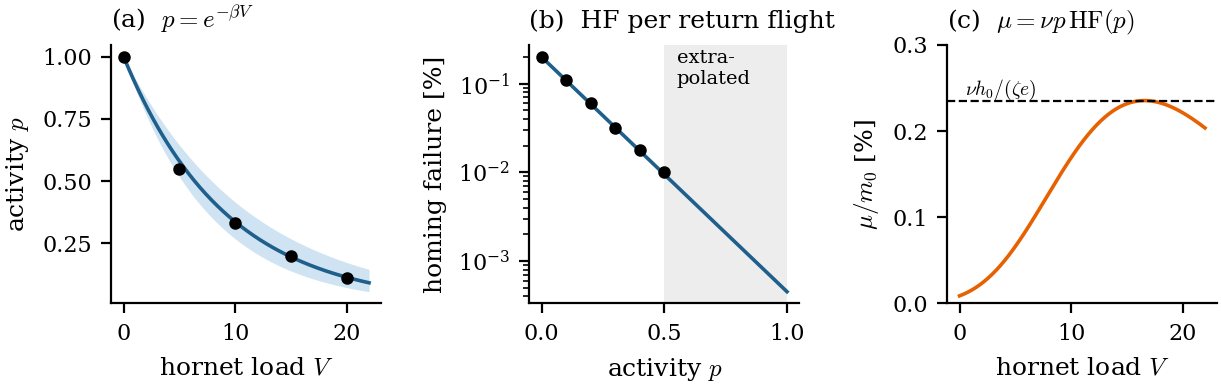

In [10]:
show("calibration")

## Chapter 5.1  The cascade and the existence band

All thresholds in $p$ share the same form (Eq. 5.30):
$$p_X = \frac{\gamma_A(1+X) + \kappa m}{c}.$$

* **Accumulation edge** $X = Q$: $J_Q = 1/Q$ is the positive root of $mJ^2 + (m + \sigma - \alpha_{\min})J - \alpha_{\min}$.
* **Existence edge** $X = P_c = mv/(Ls^*)$: $s^*$ is the positive root of
  $(\omega^2 + \omega\alpha_{\max})s^2 + [\omega(\sigma + m - \alpha_\Sigma) + m\alpha_{\max}]s - m\alpha_\Sigma$ with $\omega = L/v$.

In [11]:
m = m0
# accumulation edge
J_Q = max(np.roots([m, m + P.sigma - P.amin, -P.amin]).real)
Q   = 1 / J_Q
p_acc = (P.gA * (1 + Q) + P.kap * m) / P.c
check("Q", Q, "2.8334")
check("p_acc", p_acc, "0.517818")
check("V_acc", -np.log(p_acc) / P.beta, "6.04")

# existence edge
om = P.L / P.v
s_star = max(np.roots([om**2 + om * P.amax, om * (P.sigma + m - P.asum) + m * P.amax, -m * P.asum]).real)
f_crit = P.b * np.sqrt(s_star / (1 - s_star))
P_c    = m * P.v / (P.L * s_star)
p_star = (P.gA * (1 + P_c) + P.kap * m) / P.c
check("s*", s_star, "0.281699")
check("f_crit [g]", f_crit, "313.12")
check("p*", p_star, "0.415150")
check("V*", -np.log(p_star) / P.beta, "8.07")

# existence edge on the mortality axis at p = 1
m_star = brentq(lambda mm: tc.p_star(mm) - 1, 0.2, 1.0)
check("m*", m_star, "0.4624055")
check("m* / m0", m_star / m0, "3.00")

✓  Q                                                code: 2.833406       thesis: 2.8334
✓  p_acc                                            code: 0.5178184      thesis: 0.517818
✓  V_acc                                            code: 6.037896       thesis: 6.04
✓  s*                                               code: 0.2816987      thesis: 0.281699
✓  f_crit [g]                                       code: 313.1188       thesis: 313.12
✓  p*                                               code: 0.4151496      thesis: 0.415150
✓  V*                                               code: 8.065288       thesis: 8.07
✓  m*                                               code: 0.4624055      thesis: 0.4624055
✓  m* / m0                                          code: 3.002633       thesis: 3.00


**The band numerically.** For each $p$ the cascade is evaluated (`tc.equilibrium`). A positive
equilibrium exists exactly for $p^* < p < p_{\mathrm{acc}}$ (Figure 5.2).

exists exactly inside the band: True


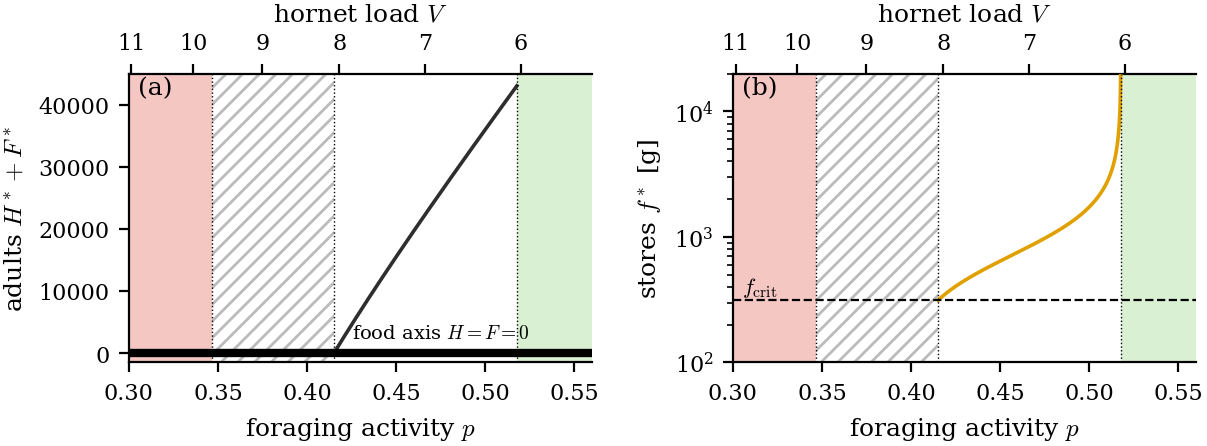

In [12]:
p_grid = np.linspace(0.30, 0.60, 30001)
exists = np.array([tc.equilibrium(p, m0) is not None for p in p_grid])
print("exists exactly inside the band:", np.all(exists == ((p_grid > p_star) & (p_grid < p_acc))))
show("band")

## Chapter 5.2  Local stability

For $\lambda^3 + a_1\lambda^2 + a_2\lambda + a_3$ Routh–Hurwitz requires $a_1 > 0$, $a_3 > 0$ and $a_1a_2 > a_3$.
The thesis proves this in general. Here the formulas (5.13) and (5.15) are checked and Table 5.1 is recomputed.

In [13]:
p = 0.45
x = tc.equilibrium(p, m0)
J_an  = tc.jac_analytic(x, p, m0)
J_num = tc.jac_numeric(lambda z: tc.rhs_M(0, z, p, m0), x)
print("analytic = numerical:", np.allclose(J_an, J_num, rtol=1e-5))

a1, a2, a3 = tc.char_coeffs(J_an)
print(f"a1 = {a1:.6f}   formula (5.13): {tc.a1_formula(x, m0):.6f}")
print(f"a3 = {a3:.3e}   formula (5.15): {tc.a3_formula(x, m0):.3e}")
print("Routh-Hurwitz satisfied:", a1 > 0 and a3 > 0 and a1 * a2 > a3)

analytic = numerical: True
a1 = 0.855924   formula (5.13): 0.855924
a3 = 1.328e-03   formula (5.15): 1.328e-03
Routh-Hurwitz satisfied: True


In [14]:
print(f"{'p':>7} {'V':>6} {'Re lambda':>12} {'relax. [d]':>11} {'delay [d]':>10}")
for p in [0.416, 0.43, 0.45, 0.48, 0.51, 0.517]:
    lam = tc.slow_eig(p, m0)[0].real
    A0, A1, y = tc.delay_linearisation(p, m0)
    lamD = tc.rightmost_real_root(A0, A1, P.tau, lam)
    print(f"{p:7.3f} {-np.log(p)/P.beta:6.2f} {lam:12.6f} {1/abs(lam):11.0f} {1/abs(lamD):10.0f}")

      p      V    Re lambda  relax. [d]  delay [d]
  0.416   8.05    -0.000178        5631       9576
  0.430   7.74    -0.002826         354        569
  0.450   7.33    -0.005673         176        263
  0.480   6.73    -0.007947         126        169
  0.510   6.18    -0.004103         244        267
  0.517   6.05    -0.000206        4846       4863


## Chapter 5.3  Energy budget and global collapse

**Budget identity (Lemma 5.12).** With $W_\kappa = f + \kappa(H+F)$
$$\dot W_\kappa = cF(p - p_\kappa) - \gamma_A H.$$
This is checked at random states, without any simulation.

In [15]:
rng = np.random.default_rng(0)
p_kap = (P.gA + P.kap * m0) / P.c
error = 0
for _ in range(2000):
    H, F, f = 10 ** rng.uniform(-2, 5, 3)
    p = rng.uniform(0, 1)
    dH, dF, df = tc.rhs_M(0, (H, F, f), p, m0)
    lhs = df + P.kap * (dH + dF)
    rhs = P.c * F * (p - p_kap) - P.gA * H
    error = max(error, abs(lhs - rhs) / max(1, abs(rhs)))
print("largest relative error:", error)

p_E = (P.gA + P.astar * m0) / P.c
check("p_kappa", p_kap, "0.319480")
check("p_E", p_E, "0.346430")
check("V_E", -np.log(p_E) / P.beta, "9.73")

largest relative error: 3.737996997884278e-14
✓  p_kappa                                          code: 0.31948        thesis: 0.319480
✓  p_E                                              code: 0.34643        thesis: 0.346430
✓  V_E                                              code: 9.725454       thesis: 9.73


**Theorem 5.17 in action.** For $p < p_E$ the energy capital $W = f + a_\star(H+F)$ decreases along every
solution, and the colony dies. The simulation uses LSODA with rationing (`tc.simulate_M`).

In [16]:
for name, x0 in tc.STATES.items():
    sol = tc.simulate_M(0.30, m0, x0, 2000.0, ration=True)
    W = tc.W_of(sol["x"], P.astar)
    print(f"state {name}: W decreasing: {np.all(np.diff(W) <= 1e-6 * W[0])},  stores left {sol['x'][2, -1]:.1f} g")

state A: W decreasing: True,  stores left 250.6 g
state B: W decreasing: True,  stores left 250.6 g
state C: W decreasing: True,  stores left 250.6 g
state D: W decreasing: True,  stores left 258.3 g


In [17]:
print("stores left from the healthy state B (Table B.6):")
for p, thesis in [(0.15, "104.5"), (0.20, "172.1"), (0.25, "216.0"), (0.30, "250.6"), (0.319, "262.2")]:
    sol = tc.simulate_M(p, m0, tc.HEALTHY, 6000.0)
    check(f"f_inf at p = {p}", sol["x"][2, -1], thesis, tol=0.1)

stores left from the healthy state B (Table B.6):
✓  f_inf at p = 0.15                                code: 104.4982       thesis: 104.5
✓  f_inf at p = 0.2                                 code: 172.0758       thesis: 172.1
✓  f_inf at p = 0.25                                code: 216.0251       thesis: 216.0


✓  f_inf at p = 0.3                                 code: 250.6112       thesis: 250.6


✓  f_inf at p = 0.319                               code: 262.2466       thesis: 262.2


**The two end states (Figure 5.1).** (a) Below the existence edge the colony empties while stores
remain. (b) Under heavy paralysis the stores run out first; with rationing the colony lives on the
empty comb a little longer.

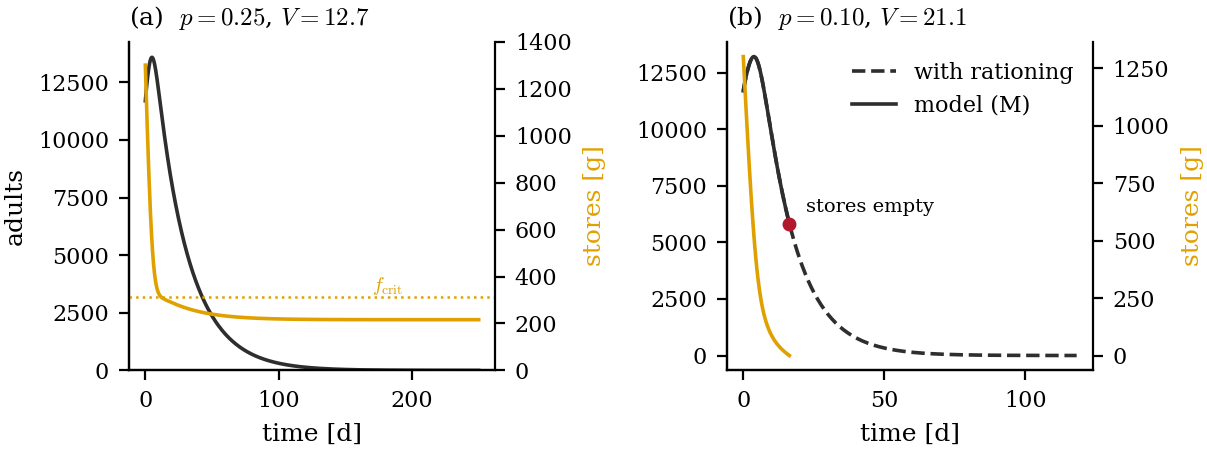

In [18]:
show("endstates")

## Chapter 5.4  The food axis

Near $H = F = 0$ a small colony grows or shrinks at the rate
$$\lambda(f) = A(f)(1-u^*) - m u^*,\qquad A = \omega s(f),\quad u^* = \frac{\alpha(f)}{\sigma + A + m}.$$
Its root is exactly $f_{\mathrm{crit}}$: below it the axis attracts, above it the axis repels.

In [19]:
print(f"lambda(f_crit) = {tc.lam_of(f_crit, m0):.2e}")
for f, thesis in [(250, "-0.027012"), (400, "0.038377"), (800, "0.168960")]:
    check(f"lambda({f})", tc.lam_of(float(f), m0), thesis)

lambda(f_crit) = 1.39e-17
✓  lambda(250)                                      code: -0.0270122     thesis: -0.027012
✓  lambda(400)                                      code: 0.03837692     thesis: 0.038377
✓  lambda(800)                                      code: 0.1689602      thesis: 0.168960


**The collision at the existence edge (Figure 5.3, Remark 5.28).** In the blow-up coordinates
$u = F/N$, $N^{1/3}$ and $f$ the food axis becomes the curve $\Gamma = \{N = 0,\ u = u^*(f)\}$,
attracting below $f_{\rm crit}$ (red) and repelling above (blue). The black curve is the branch of
positive equilibria, which meets $\Gamma$ at $f_{\rm crit}$ as $p \downarrow p^*$.

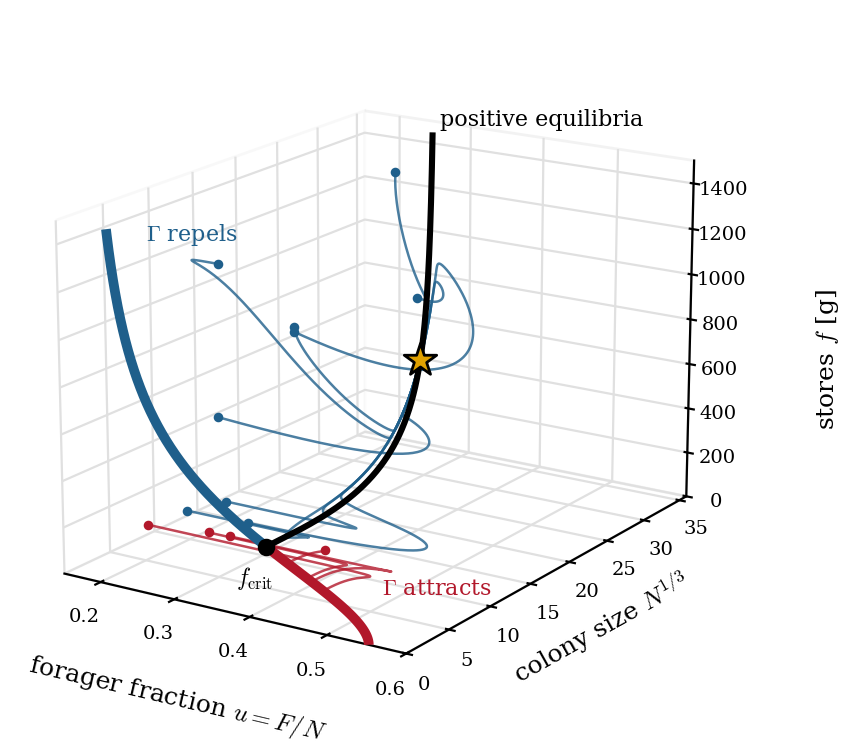

In [20]:
show("axis3d")

**Basins of attraction (Figure 5.4, Remark 5.30).** For each initial size $N_0$ a bisection in $f_0$
finds the boundary between collapse and the positive equilibrium. As $N_0 \to 0$ the boundary tends to
$f_{\rm crit}$, but for larger colonies it lies below: $f_{\rm crit}$ governs only colonies close to extinction.
This cell takes about half a minute.

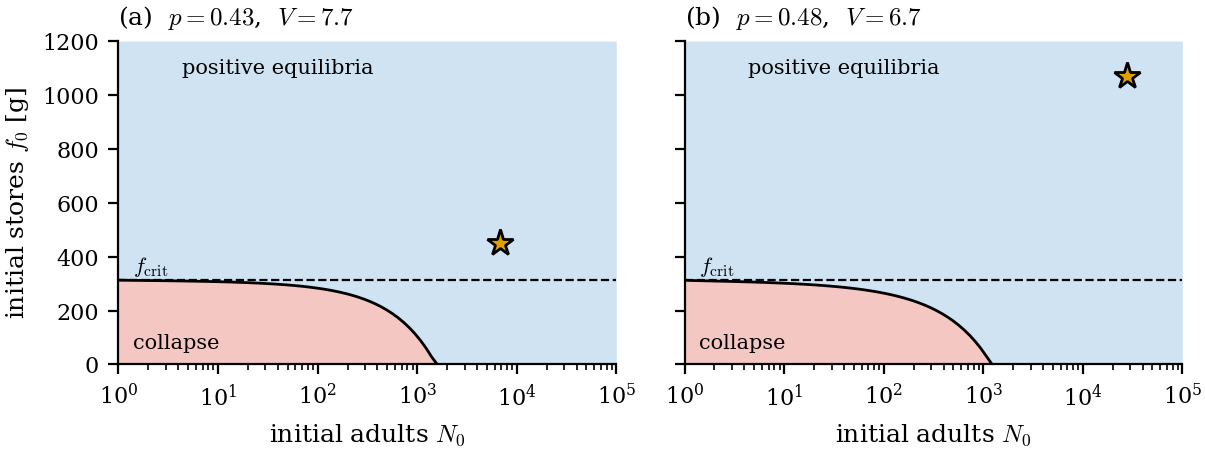

In [21]:
show("basins")

## Chapter 5.5  The ladder

All four thresholds are $p_X$ with increasing $X$: $0 < mv/L < P_c < Q$. This gives the ordering, and the
width of the window is
$$p^* - p_E = \frac{\gamma_A m v}{cL}\cdot\frac{1-s^*}{s^*}.$$

In [22]:
pX = lambda X: (P.gA * (1 + X) + P.kap * m0) / P.c
for name, X in [("p_kappa", 0), ("p_E", m0 * P.v / P.L), ("p*", P_c), ("p_acc", Q)]:
    print(f"{name:>8}:  X = {X:6.3f}   p = {pX(X):.6f}   V = {-np.log(pX(X))/P.beta:6.2f}")
width = P.gA * m0 * P.v / (P.c * P.L) * (1 - s_star) / s_star
check("window width p* - p_E", width, "0.0687")

 p_kappa:  X =  0.000   p = 0.319480   V =  10.47
     p_E:  X =  0.385   p = 0.346430   V =   9.73
      p*:  X =  1.367   p = 0.415150   V =   8.07
   p_acc:  X =  2.833   p = 0.517818   V =   6.04
✓  window width p* - p_E                            code: 0.06871958     thesis: 0.0687


## Chapter 6  The two channels

### Q2: Which capture rate would move the existence edge by one hornet?
We need $\Delta m$ with $p^*(m_0 + \Delta m) = p(V^* - 1)$. A forager makes $\nu p$ flights per day.

In [23]:
V_target = -np.log(p_star) / P.beta - 1
p_target = np.exp(-P.beta * V_target)
dm = brentq(lambda mm: tc.p_star(mm) - p_target, m0, 1.0) - m0
capture = dm / (P.nu * p_target)
check("required Delta m", dm, "0.025")
check("required capture rate [%]", 100 * capture, "1.8")
check("... as a multiple of h0", capture / P.h0, "9", tol=0.5)

✓  required Delta m                                 code: 0.02482578     thesis: 0.025
✓  required capture rate [%]                        code: 1.787471       thesis: 1.8
✓  ... as a multiple of h0                          code: 8.937354       thesis: 9


### Q3: The decomposition $851 = 51 \times 17$
$$\frac{m^* - m_0}{\max\mu} = \underbrace{\frac{m^* - m_0}{\nu h_0}}_{\text{rarity}}\cdot\underbrace{\zeta e}_{\text{behaviour}}.$$

In [24]:
check("(m* - m0) / max mu", (m_star - m0) / mu_max, "851", tol=1)
check("(m* - m0) / (nu h0)", (m_star - m0) / (P.nu * P.h0), "51", tol=0.5)
check("zeta e", P.zeta * math.e, "17", tol=0.5)

✓  (m* - m0) / max mu                               code: 850.9081       thesis: 851
✓  (m* - m0) / (nu h0)                              code: 51.40092       thesis: 51
✓  zeta e                                           code: 16.55434       thesis: 17


**The $(p, m)$ plane (Figure 6.1).** (a) The hornet trajectory $V \mapsto (p(V),\, m_0 + \mu(V))$ crosses
all thresholds horizontally: it moves along the activity axis and barely along the mortality axis.
(b) The same trajectory with the mortality axis stretched by a factor of $10^4$.

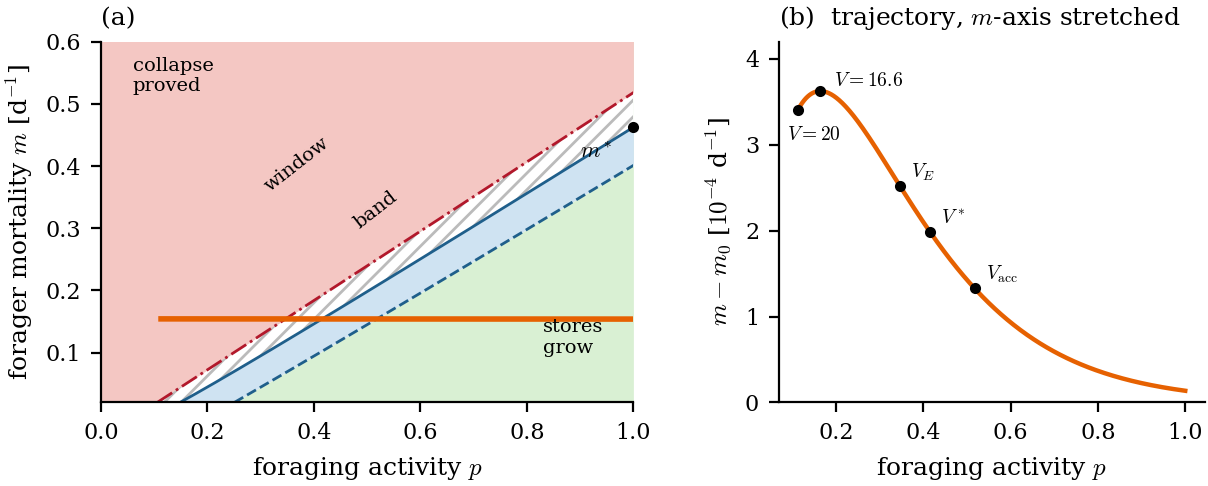

In [25]:
show("pm")

### 6.3  Sensitivity: $\beta$ and the structural bracket $\theta$
For $\theta > 0$ the mortality itself depends on $p$: $m(p) = m_0[(1-\theta) + \theta p] + \mu(p)$.
Each threshold is then a fixed point $p = T(m(p))$, solved with `brentq`.

In [26]:
print("beta     V_acc    V*     V_E")
for b in [0.087, 0.107, 0.109, 0.120, 0.131]:
    print(f"{b:.3f}  {-np.log(p_acc)/b:6.2f} {-np.log(p_star)/b:6.2f} {-np.log(p_E)/b:6.2f}")

print("\ntheta   V_acc    V*     V_E")
for th in [0, 0.25, 0.5, 0.75, 1.0]:
    m_of_p = lambda p, th=th: m0 * ((1 - th) + th * p) + tc.mu_of_p(p)
    values = [-np.log(tc.threshold_with_m_of_p(k, m_of_p)) / P.beta for k in ("acc", "star", "E")]
    print(f"{th:5.2f}  " + "  ".join(f"{v:6.2f}" for v in values))

beta     V_acc    V*     V_E
0.087    7.56  10.10  12.18
0.107    6.15   8.22   9.91
0.109    6.04   8.07   9.73
0.120    5.48   7.33   8.83
0.131    5.02   6.71   8.09

theta   V_acc    V*     V_E
 0.00    6.03    8.06    9.71
 0.25    6.76    9.16   11.09
 0.50    7.71   10.66   13.01
 0.75    8.99   12.90   15.92
 1.00   10.87   16.87   21.35


### 6.4  Seasonal store balance
The load at which a colony ends $T$ days with as much food as it started with: $f(T; V) = f_0$.

In [27]:
from scipy.integrate import solve_ivp

def store_change(V, x0, T):
    p, mm = np.exp(-P.beta * V), m0 + tc.mu_of_V(V)
    sol = solve_ivp(tc.rhs_M, (0, T), x0, method="LSODA", args=(p, mm), rtol=1e-9, atol=1e-9)
    return sol.y[2, -1] - x0[2]

for T in (70, 150):
    loads = [brentq(store_change, 3, 9, args=(x0, T), xtol=1e-4) for x0 in tc.STATES.values()]
    print(f"T = {T:3d} d:  " + "  ".join(f"{v:.2f}" for v in loads), "  (states A-D)")

T =  70 d:  5.53  5.67  6.01  5.92   (states A-D)
T = 150 d:  5.83  6.23  6.78  6.79   (states A-D)


## The delay model (Theorem 5.20, Appendix B.2)

Fixed-step RK4 with a stored brood history (`tc.dde_rk4`). At $V = 11$ the colony collapses, and
$W_D = f + a_\star(H + F + \Pi) + (a_\star - \kappa)B$ never increases.

In [28]:
V = 11.0
r = tc.dde_rk4(np.exp(-P.beta * V), m0 + tc.mu_of_V(V), (0.0, 16000.0, 8000.0, 800.0), 4000.0, track_W=True)
B, H, F, f = r["final"]
print(f"H + F after 4000 d: {H + F:.2e}   largest increase of W_D: {r['dWmax']}")

H + F after 4000 d: 9.33e-27   largest increase of W_D: 0.0


In [29]:
SLOW = False     # set to True for Table B.3 (about one minute)
if SLOW:
    for model in ("delay", "tau0", "M3"):
        print(model, tc.survival_thresholds(model))

## Full verification

The next cell runs the complete report (527 checks in quick mode) against the values printed in the
thesis and writes `verification_report.txt` and `verification_report.csv`. Only the summary and the
deviations are shown here. Nine DIFF lines remain. Most of them are rounding in the last printed digit
or come from rounded intermediate values, and the note column explains each one.

In [30]:
import io, contextlib
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    tc.main(["--quick", "--no-figs"])
for line in buffer.getvalue().splitlines():
    if "[DIFF]" in line or "[FAIL]" in line or "checks:" in line:
        print(line)

  [DIFF] Tab. B.1           fit exp(-0.1098 V) at V=5                            thesis=0.577        code=0.57752705 (0.5775 -> 0.578)
  [DIFF] App. B.1           LS fit of ln HF: zeta                                thesis=6.03         code=6.0249564 (6.02496: rounds to 6.02, write 6.025)
  [DIFF] App. C.1.2         X                                                    thesis=0.12824      code=0.12822519 (thesis divides the rounded 0.03206)
  [DIFF] App. C.1.2         s(f*)                                                thesis=0.87175      code=0.87177481 (exact 0.87178)
  [DIFF] App. C.1.2         B* = m F/phi                                         thesis=10391.6      code=10391.47 (thesis uses rounded F=2749.1)
  [DIFF] Sec. 5.3.4         p=0.25, max residual over A-D [g]                    thesis=229.5        code=239.26056 (state D; the thesis figure 229.5 must come from other initial states)
  [DIFF] Tab. A.3           mu at V=6.0                                          thesis=1.